# 03 - Exploratory Data Analysis

**What :** An Exploratory Data Analysis notebook that examines the statistical properties of the MXN/USD return series — distributions, volatility clustering, fat tails, and autocorrelation structure.

**Why :** This notebook is the argument of the project. It's where we prove empirically that the Black-Scholes assumptions break down. Every modeling choice that comes later — GARCH over simple volatility, Student-t over normal, HMM for regimes — gets justified here with data. Without this notebook, the model is just a choice. With it, the model is a conclusion.

  **How :** We use a combination of statistical tests, visualizations, and summary statistics to paint a comprehensive picture of the return series. We look for evidence of non-normality, volatility clustering, and regime shifts — all phenomena that violate Black-Scholes assumptions and motivate our modeling approach.

## 0. Setup

In [1]:
import sys
import pandas as pd
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.data.validate import run_all        # ← ImportError: attempted relative…

mxn = pd.read_csv(ROOT / "data/raw/mxn_usd.csv", index_col="Date", parse_dates=True)
ipc = pd.read_csv(ROOT / "data/raw/ipc.csv", index_col="Date", parse_dates=True)
macro = pd.read_csv(ROOT / "data/raw/macro.csv", index_col=0, parse_dates=True)

max_mxn = mxn['MXN_USD'].max()
min_mxn = mxn['MXN_USD'].min()
print(f"MXN/USD range: {min_mxn:.2f} - {max_mxn:.2f}")

MXN/USD range: 8.94 - 25.12


## 1. Log Returns

The first thing we always do with a financial time series is compute log returns:
$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$
Why log returns and not simple returns? Two reasons: 
* they're additive over time, 
* and they're approximately symmetric around zero — which makes them easier to model statistically.

In [2]:
import numpy as np

returns = np.log(mxn['MXN_USD'] / mxn['MXN_USD'].shift(1)).dropna()
returns.name = 'log_return'

## 2. Return Distribution

The next thing we look at is the distribution of returns. We plot a histogram and overlay a normal distribution with the same mean and standard deviation. We also compute summary statistics like skewness and kurtosis.

In [ ]:
from scipy.stats import norm, skew, kurtosis

mu, sigma = np.mean(returns), np.std(returns)

x = np.linspace(min(returns), max(returns), 100)
pdf = norm.pdf(x, mu, sigma)

print(f"Mean: {mu:.4f}")
print(f"Std Dev: {sigma:.4f}")
print(f"Skewness: {skew(returns):.4f}")
print(f"Kurtosis: {kurtosis(returns, fisher=True):.4f}")

plt.hist(returns, bins=30, density=True)
plt.plot(x, pdf)
plt.show()

Mean: 0.0001
Std Dev: 0.0068
Skewness: 0.7792
Kurtosis: 10.3022


NameError: name 'plt' is not defined

The summary statistics show that the returns are not normally distributed — they have significant skewness and excess kurtosis. This is another key stylized fact that motivates our use of Student-t distributions later on.

# 3. Volatility Clustering

<Axes: title={'center': 'MXN/USD Log Returns'}, xlabel='Date'>

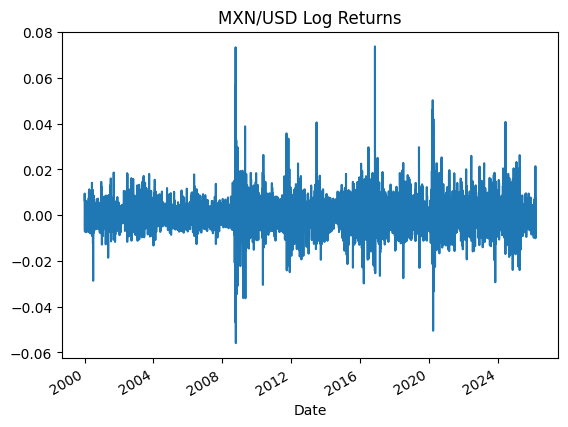

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

returns.plot(title='MXN/USD Log Returns')

We observe the phenomena of volatility clustering — periods of high volatility followed by more high volatility, and periods of low volatility followed by more low volatility. This is a key stylized fact that motivates our use of GARCH models later on. In aprticular, we identify in the yeears 2000, 2008, 2016 and 2020 as periods of high volatility, due historical events such as the dot-com bubble, the global financial crisis, the US elections and the COVID-19 pandemic.

# 4. Autocorrelation Structure

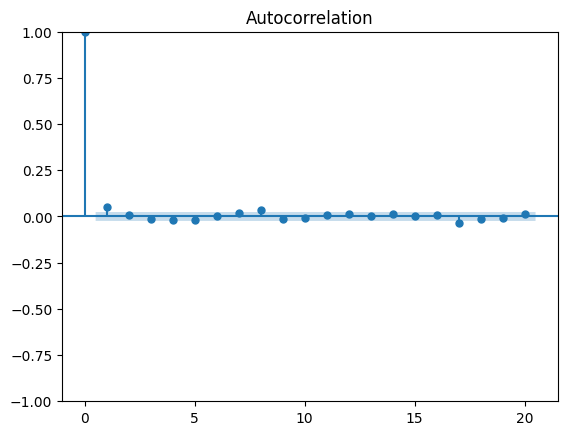

Autocorrelation (lag 1): 0.0491


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(returns, lags=20)
plt.show()

autocorr = returns.autocorr(lag=1)
print(f"Autocorrelation (lag 1): {autocorr:.4f}")

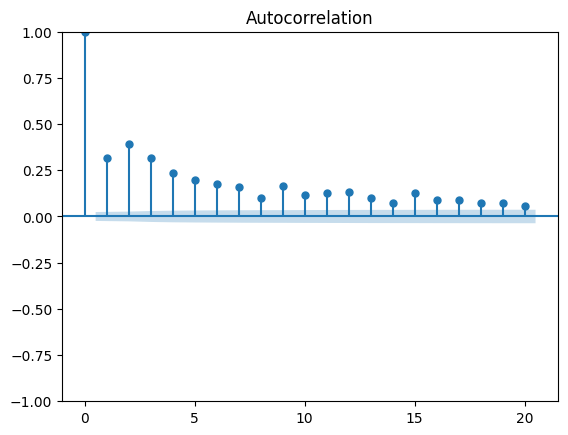

Autocorrelation of squared returns (lag 1): 0.3158


In [ ]:
s_returns = returns ** 2
plot_acf(s_returns, lags=20)
plt.show()
print(f"Autocorrelation of squared returns (lag 1): {s_returns.autocorr(lag=1):.4f}")

We look at the autocorrelation function (ACF) of the returns and squared returns. The returns themselves show little to no autocorrelation, which is consistent with the idea that price changes are unpredictable. However, the squared returns show significant autocorrelation, which is evidence of volatility clustering. This is another stylized fact that violates the assumptions of Black-Scholes and motivates our modeling choices.

## 5. Rolling Volatility

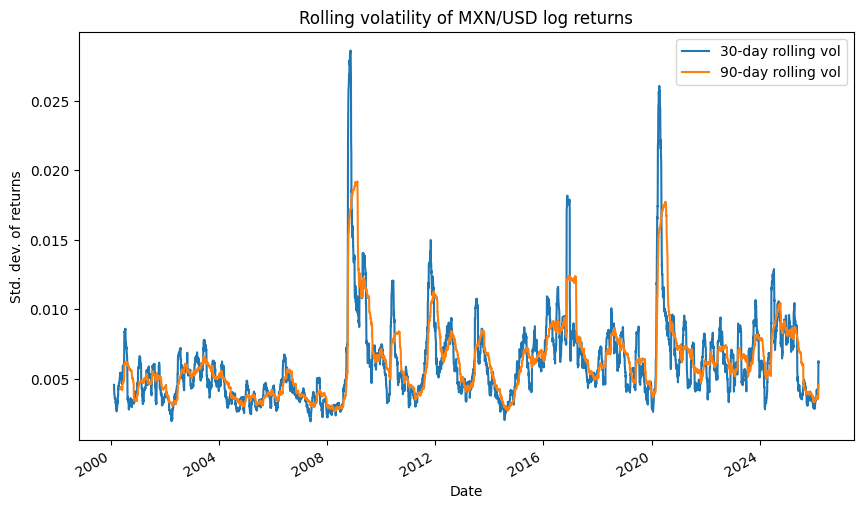

In [ ]:
# 30‑day and 90‑day rolling standard deviation of the log returns
vol_30 = returns.rolling(window=30).std()
vol_90 = returns.rolling(window=90).std()

plt.figure(figsize=(10, 6))
vol_30.plot(label='30‑day rolling vol')
vol_90.plot(label='90‑day rolling vol')
plt.title('Rolling volatility of MXN/USD log returns')
plt.ylabel('Std. dev. of returns')
plt.legend()
plt.show()

Rolling volatility is a simple way to visualize how volatility changes over time. We compute 30-day and 90-day rolling standard deviations of the log returns and plot them. This gives us a visual representation of volatility clustering and regime shifts in the data. We can see periods where volatility spikes — these often correspond to market events or crises — and periods where volatility is low and stable. This further reinforces the idea that volatility is not constant, which is a key violation of Black-Scholes assumptions.

## 6. Summary of Stylized Facts

In [ ]:
print("Summary of Stylized Facts for MXN/USD Log Returns:")
print(f"- Mean: {mu:.6f}, Std Dev: {sigma:.6f}")
print(f"- Skewness: {skew(returns):.4f} (non-zero indicates asymmetry)")
print(f"- Excess Kurtosis: {kurtosis(returns, fisher=True):.4f} (positive indicates fat tails)")
print("- Volatility Clustering: Periods of high/low volatility persist over time.")
print(f"- Autocorrelation (lag 1): {autocorr:.4f} (near zero for returns)")
print(f"- Autocorrelation of Squared Returns (lag 1): {s_returns.autocorr(lag=1):.4f} (significant, indicating volatility clustering)")
print("- Rolling Volatility: Varies over time, with spikes during crises (e.g., 2000, 2008, 2016, 2020).")
print("- These facts violate Black-Scholes assumptions, motivating GARCH, Student-t, and HMM models.")

Summary of Stylized Facts for MXN/USD Log Returns:
- Mean: 0.000097, Std Dev: 0.006841
- Skewness: 0.7792 (non-zero indicates asymmetry)
- Excess Kurtosis: 10.3022 (positive indicates fat tails)
- Volatility Clustering: Periods of high/low volatility persist over time.
- Autocorrelation (lag 1): 0.0491 (near zero for returns)
- Autocorrelation of Squared Returns (lag 1): 0.3158 (significant, indicating volatility clustering)
- Rolling Volatility: Varies over time, with spikes during crises (e.g., 2000, 2008, 2016, 2020).
- These facts violate Black-Scholes assumptions, motivating GARCH, Student-t, and HMM models.
